<a href="https://colab.research.google.com/github/ahmedlakbar-stack/ProjetS/blob/main/SQLInjection_XSS_MixDatasetF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("alextrinity/sqli-xss-dataset")

print("Path to dataset files:", path)

100%|██████████| 62.0M/62.0M [00:00<00:00, 79.4MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/alextrinity/sqli-xss-dataset/versions/2


In [ ]:


# ============================================================
# 0. IMPORTS
# ============================================================

import pandas as pd
import numpy as np
import os
import re
import math
from collections import Counter
from urllib.parse import unquote

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score
)

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.preprocessing import (
    LabelEncoder,
    RobustScaler
)

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.base import BaseEstimator, TransformerMixin

import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")




In [ ]:
# ============================================================
# 1. INGESTION
# ============================================================

path = "/root/.cache/kagglehub/datasets/alextrinity/sqli-xss-dataset/versions/2"

files = os.listdir(path)

csv_file = [f for f in files if f.endswith(".csv")][0]

df = pd.read_csv(os.path.join(path, csv_file))

print("Dataset shape:", df.shape)

print(df.head())

print(df.info())

Dataset shape: (206636, 5)
                                            Sentence  SQLInjection  XSS  \
0                      " or pg_sleep ( __TIME__ ) --           1.0  0.0   
1  create user name identified by pass123 tempora...           1.0  0.0   
2                                                %29           1.0  0.0   
3  ' AND 1 = utl_inaddr.get_host_address  (  (  S...           1.0  0.0   
4   select * from users where id = '1' or @ @1 = ...           1.0  0.0   

   CommandInjection  Normal  
0               0.0     0.0  
1               0.0     0.0  
2               0.0     0.0  
3               0.0     0.0  
4               0.0     0.0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 206636 entries, 0 to 206635
Data columns (total 5 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Sentence          206636 non-null  object 
 1   SQLInjection      206636 non-null  float64
 2   XSS               206636 non-null  

In [ ]:

# ============================================================
# 2. CLEANING
# ============================================================

# remove duplicates
df.drop_duplicates(inplace=True)

# remove nulls
df.dropna(inplace=True)

print("\nAfter cleaning:", df.shape)


After cleaning: (199800, 5)


In [ ]:
# ============================================================
# 3. LABEL CREATION
# ============================================================

def combine_labels(row):

    if row['SQLInjection'] == 1:
        return "SQLi"

    elif row['XSS'] == 1:
        return "XSS"

    else:
        return "Normal"

df['label'] = df.apply(combine_labels, axis=1)

print(df['label'].value_counts())

label
Normal    101771
SQLi       57280
XSS        40749
Name: count, dtype: int64


In [ ]:
# ============================================================
# 4. LABEL ENCODING
# ============================================================

le = LabelEncoder()

df['label_encoded'] = le.fit_transform(df['label'])

In [ ]:
# ============================================================
# 5. URL DECODING
# ============================================================

def multi_decode(text):

    text = str(text)

    for _ in range(3):

        try:
            decoded = unquote(text)

            if decoded == text:
                break

            text = decoded

        except:
            break

    return text

df['decoded'] = df['Sentence'].apply(multi_decode)

In [ ]:
# ============================================================
# 6. SECURITY PREPROCESSING
# ============================================================

def clean_security_text(text):

    text = str(text).lower()

    # keep security patterns
    text = re.sub(r"\s+", " ", text)

    return text.strip()

df['cleaned'] = df['decoded'].apply(clean_security_text)


In [ ]:
# ============================================================
# 7. ENTROPY
# ============================================================

def entropy(text):

    if len(text) == 0:
        return 0

    probabilities = [v / len(text) for v in Counter(text).values()]

    return -sum(p * math.log2(p) for p in probabilities)

df['entropy'] = df['cleaned'].apply(entropy)


In [ ]:

# ============================================================
# 8. FEATURE ENGINEERING
# ============================================================

# payload length
df['length'] = df['cleaned'].apply(len)

# special chars count
df['special_chars'] = df['cleaned'].apply(
    lambda x: sum(not c.isalnum() for c in str(x))
)

# special ratio
df['special_ratio'] = (
    df['special_chars'] / (df['length'] + 1)
)

# encoded chars
df['encoded_chars'] = df['Sentence'].apply(
    lambda x: len(re.findall(r"%[0-9a-fA-F]{2}", str(x)))
)

# SQL keywords
sql_pattern = r"""
select|union|drop|insert|delete|update|
or\s+1=1|sleep\(|benchmark\(|information_schema|
xp_cmdshell|exec|--|#
"""

df['sql_kw'] = df['cleaned'].str.contains(
    sql_pattern,
    case=False,
    regex=True
).astype(int)

# XSS keywords
xss_pattern = r"""
<script|javascript:|onerror|onload|
alert\(|document\.cookie|svg|iframe|
img|prompt\(|confirm\(
"""

df['xss_kw'] = df['cleaned'].str.contains(
    xss_pattern,
    case=False,
    regex=True
).astype(int)

In [ ]:

# ============================================================
# 9. OPTIONAL HTTP FEATURES
# ============================================================

# fake method feature (if dataset doesn't contain methods)

df['method'] = np.random.choice(
    ['GET', 'POST'],
    size=len(df)
)

# one-hot encoding
df = pd.get_dummies(df, columns=['method'])

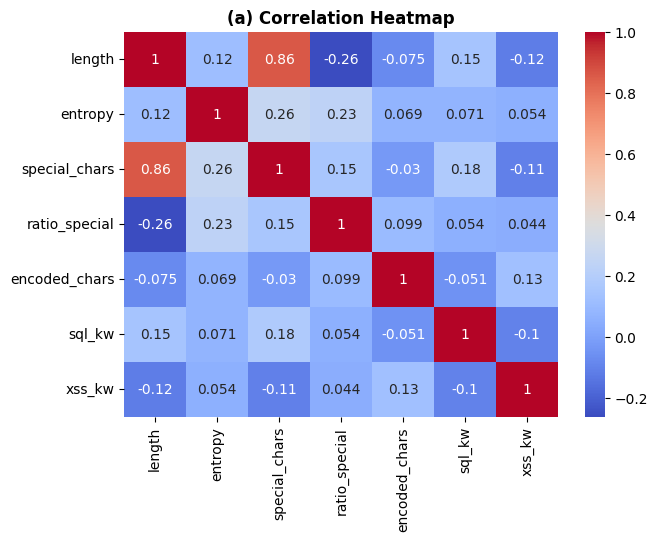

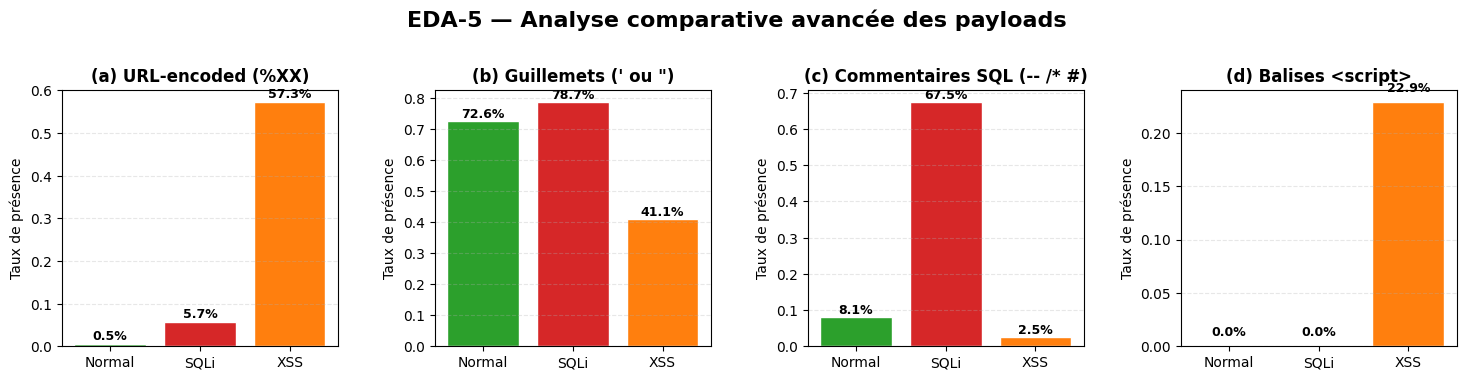

In [ ]:

# ============================================================
# 10. EDA
# ============================================================



# ratio caractères spéciaux
df["ratio_special"] = (
    df["special_chars"] / (df["length"] + 1)
)

# payload URL-encoded
df["has_encoded"] = df["Sentence"].apply(
    lambda x: int(bool(
        re.search(r"%[0-9a-fA-F]{2}", str(x))
    ))
)

# présence quotes
df["has_quote"] = df["Sentence"].apply(
    lambda x: int(
        ("'" in str(x)) or ('"' in str(x))
    )
)

# commentaires SQL
df["has_comment"] = df["Sentence"].apply(
    lambda x: int(bool(
        re.search(r"(--|#|/\*)", str(x))
    ))
)

# balises script
df["has_script_tag"] = df["Sentence"].apply(
    lambda x: int(bool(
        re.search(r"<script", str(x), re.IGNORECASE)
    ))
)

# ============================================================
# PALETTE
# ============================================================

PAL3 = {
    "SQLi": "#d62728",
    "XSS": "#ff7f0e",
    "Normal": "#2ca02c"
}

# ============================================================
# SAVE FUNCTION
# ============================================================

import os
from matplotlib import gridspec

os.makedirs("figures", exist_ok=True)

def _save(fig, name):
    fig.savefig(
        f"figures/{name}.png",
        dpi=300,
        bbox_inches="tight"
    )

# ============================================================
# EDA-4 : CORRELATIONS + VIOLIN
# ============================================================

fig, ax = plt.subplots( figsize=(7, 5))

# ------------------------------------------------------------
# (a) Correlation Heatmap
# ------------------------------------------------------------

corr_features = [
    "length",
    "entropy",
    "special_chars",
    "ratio_special",
    "encoded_chars",
    "sql_kw",
    "xss_kw"
]

corr = df[corr_features].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    ax=ax
)

ax.set_title(
    "(a) Correlation Heatmap",
    fontweight="bold"
)


# ============================================================
# EDA-5 : ANALYSE COMPARATIVE
# ============================================================

fig = plt.figure(figsize=(18, 8))

gs = gridspec.GridSpec(
    2,
    4,
    hspace=0.4,
    wspace=0.35
)

# ------------------------------------------------------------
# (a) URL ENCODED
# ------------------------------------------------------------

ax = fig.add_subplot(gs[0, 0])

encoded_rate = df.groupby("label")["has_encoded"].mean()

ax.bar(
    encoded_rate.index,
    encoded_rate.values,
    color=[PAL3[l] for l in encoded_rate.index],
    edgecolor="white"
)

for i, (lbl, val) in enumerate(encoded_rate.items()):

    ax.text(
        i,
        val + 0.01,
        f"{val:.1%}",
        ha="center",
        fontsize=9,
        fontweight="bold"
    )

ax.set_ylabel("Taux de présence")

ax.set_title(
    "(a) URL-encoded (%XX)",
    fontweight="bold"
)

ax.grid(axis="y", alpha=0.3, linestyle="--")

# ------------------------------------------------------------
# (b) QUOTES
# ------------------------------------------------------------

ax = fig.add_subplot(gs[0, 1])

quote_rate = df.groupby("label")["has_quote"].mean()

ax.bar(
    quote_rate.index,
    quote_rate.values,
    color=[PAL3[l] for l in quote_rate.index],
    edgecolor="white"
)

for i, (lbl, val) in enumerate(quote_rate.items()):

    ax.text(
        i,
        val + 0.01,
        f"{val:.1%}",
        ha="center",
        fontsize=9,
        fontweight="bold"
    )

ax.set_ylabel("Taux de présence")

ax.set_title(
    "(b) Guillemets (' ou \")",
    fontweight="bold"
)

ax.grid(axis="y", alpha=0.3, linestyle="--")

# ------------------------------------------------------------
# (c) SQL COMMENTS
# ------------------------------------------------------------

ax = fig.add_subplot(gs[0, 2])

comment_rate = df.groupby("label")["has_comment"].mean()

ax.bar(
    comment_rate.index,
    comment_rate.values,
    color=[PAL3[l] for l in comment_rate.index],
    edgecolor="white"
)

for i, (lbl, val) in enumerate(comment_rate.items()):

    ax.text(
        i,
        val + 0.01,
        f"{val:.1%}",
        ha="center",
        fontsize=9,
        fontweight="bold"
    )

ax.set_ylabel("Taux de présence")

ax.set_title(
    "(c) Commentaires SQL (-- /* #)",
    fontweight="bold"
)

ax.grid(axis="y", alpha=0.3, linestyle="--")

# ------------------------------------------------------------
# (d) SCRIPT TAGS
# ------------------------------------------------------------

ax = fig.add_subplot(gs[0, 3])

script_rate = df.groupby("label")["has_script_tag"].mean()

ax.bar(
    script_rate.index,
    script_rate.values,
    color=[PAL3[l] for l in script_rate.index],
    edgecolor="white"
)

for i, (lbl, val) in enumerate(script_rate.items()):

    ax.text(
        i,
        val + 0.01,
        f"{val:.1%}",
        ha="center",
        fontsize=9,
        fontweight="bold"
    )

ax.set_ylabel("Taux de présence")

ax.set_title(
    "(d) Balises <script>",
    fontweight="bold"
)

ax.grid(axis="y", alpha=0.3, linestyle="--")

# ============================================================
# GLOBAL TITLE
# ============================================================

fig.suptitle(
    "EDA-5 — Analyse comparative avancée des payloads",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

_save(fig, "EDA5_advanced_security")

plt.show()

In [ ]:
# ============================================================
# 11. TF-IDF
# ============================================================

# character ngrams (important for security)
char_vectorizer = TfidfVectorizer(
    analyzer='char',
    ngram_range=(2,3),
    max_features=2000
)

# word ngrams
word_vectorizer = TfidfVectorizer(
    analyzer='word',
    token_pattern=r"[\w\-\.\=\<\>\/\:\(\)\;\'\"\%]+",
    ngram_range=(1,3),
    max_features=2000
)


In [ ]:
# ============================================================
# 12. FEATURE DATAFRAME
# ============================================================

features = df[[
    'cleaned',
    'length',
    'entropy',
    'special_chars',
    'special_ratio',
    'encoded_chars',
    'sql_kw',
    'xss_kw',
    'method_GET',
    'method_POST'
]]

target = df['label_encoded']

In [ ]:
# 13. TRAIN TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    features,
    target,
    test_size=0.2,
    random_state=42,
    stratify=target
)

In [ ]:
# 14. CUSTOM TRANSFORMER
# ============================================================

class TextSelector(BaseEstimator, TransformerMixin):

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        return X['cleaned']

In [ ]:
# 15. PREPROCESSOR
# ============================================================

preprocessor = ColumnTransformer([

    (
        "char_tfidf",
        char_vectorizer,
        "cleaned"
    ),

    (
        "word_tfidf",
        word_vectorizer,
        "cleaned"
    ),

    (
        "numeric",
        RobustScaler(),
        [
            'length',
            'entropy',
            'special_chars',
            'special_ratio',
            'encoded_chars',
            'sql_kw',
            'xss_kw',
            'method_GET',
            'method_POST'
        ]
    )
])

In [ ]:
# 16. MODELS
# ============================================================

pipeline_lr = Pipeline([

    ("features", preprocessor),

    ("clf", LogisticRegression(
        max_iter=2000,
        class_weight='balanced'
    ))
])

pipeline_rf = Pipeline([

    ("features", preprocessor),

    ("clf", RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        class_weight='balanced'
    ))
])


In [ ]:
# 17. TRAINING
# ============================================================

print("\nTraining Logistic Regression...")

pipeline_lr.fit(X_train, y_train)

print("Training Random Forest...")

pipeline_rf.fit(X_train, y_train)


Training Logistic Regression...
Training Random Forest...


Pipeline(steps=[('features',
                 ColumnTransformer(transformers=[('char_tfidf',
                                                  TfidfVectorizer(analyzer='char',
                                                                  max_features=2000,
                                                                  ngram_range=(2,
                                                                               3)),
                                                  'cleaned'),
                                                 ('word_tfidf',
                                                  TfidfVectorizer(max_features=2000,
                                                                  ngram_range=(1,
                                                                               3),
                                                                  token_pattern='[\\w\\-\\.\\=\\<\\>\\/\\:\\(\\)\\;\\\'\\"\\%]+'),
                                                  'cleaned'),
                                                 ('numeric', RobustScaler(),
                                                  ['length', 'entropy',
                                                   'special_chars',
                                                   'special_ratio',
                                                   'encoded_chars', 'sql_kw',
                                                   'xss_kw', 'method_GET',
                                                   'method_POST'])])),
                ('clf',
                 RandomForestClassifier(class_weight='balanced',
                                        random_state=42))])


========== LOGISTIC REGRESSION ==========

Accuracy: 0.9927927927927928

F1 Score: 0.9927862846728989

Classification Report:

              precision    recall  f1-score   support

      Normal       0.99      1.00      0.99     20354
        SQLi       0.99      0.98      0.99     11456
         XSS       1.00      1.00      1.00      8150

    accuracy                           0.99     39960
   macro avg       0.99      0.99      0.99     39960
weighted avg       0.99      0.99      0.99     39960



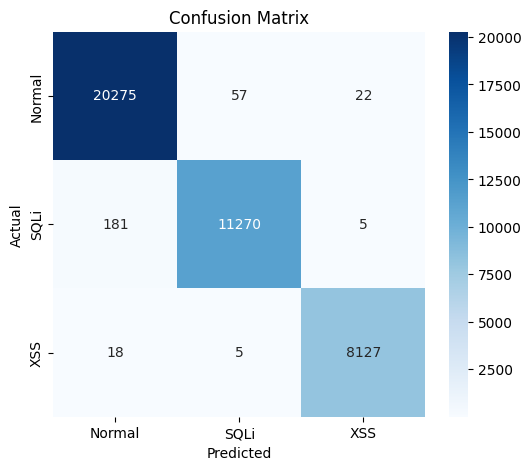

In [ ]:
# 18. EVALUATION
# ============================================================

pred_lr = pipeline_lr.predict(X_test)

print("\n========== LOGISTIC REGRESSION ==========")

print("\nAccuracy:",
      accuracy_score(y_test, pred_lr))

print("\nF1 Score:",
      f1_score(y_test, pred_lr, average='weighted'))

print("\nClassification Report:\n")

print(classification_report(
    y_test,
    pred_lr,
    target_names=le.classes_
))

# confusion matrix
cm = confusion_matrix(y_test, pred_lr)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

In [ ]:
# 19. CROSS VALIDATION
# ============================================================

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_val_score(
    pipeline_lr,
    features,
    target,
    cv=cv,
    scoring='f1_weighted'
)

print("\nCross Validation F1 Scores:")

print(scores)

print("\nAverage F1:", scores.mean())

NameError: name 'StratifiedKFold' is not defined

In [ ]:
# 20. REAL TIME PREDICTION
# ============================================================

def extract_features(payload):

    decoded = multi_decode(payload)

    cleaned = clean_security_text(decoded)

    length = len(cleaned)

    special_chars = sum(
        not c.isalnum() for c in cleaned
    )

    special_ratio = (
        special_chars / (length + 1)
    )

    encoded_chars = len(
        re.findall(r"%[0-9a-fA-F]{2}", payload)
    )

    ent = entropy(cleaned)

    sql_kw = int(bool(re.search(
        sql_pattern,
        cleaned,
        re.IGNORECASE
    )))

    xss_kw = int(bool(re.search(
        xss_pattern,
        cleaned,
        re.IGNORECASE
    )))

    row = pd.DataFrame([{
        'cleaned': cleaned,
        'length': length,
        'entropy': ent,
        'special_chars': special_chars,
        'special_ratio': special_ratio,
        'encoded_chars': encoded_chars,
        'sql_kw': sql_kw,
        'xss_kw': xss_kw,
        'method_GET': 1,
        'method_POST': 0
    }])

    return row

In [ ]:
# 21. INTERACTIVE TEST
# ============================================================

while True:

    payload = input("\nEnter payload (or exit): ")

    if payload.lower() == "exit":
        break

    data = extract_features(payload)

    prediction = pipeline_lr.predict(data)

    label = le.inverse_transform(prediction)[0]

    probabilities = pipeline_lr.predict_proba(data)[0]

    print("\nPrediction:", label)

    print("\nProbabilities:")

    for i, cls in enumerate(le.classes_):
        print(f"{cls}: {probabilities[i]:.4f}")


Enter payload (or exit): <script


NameError: name 'extract_features' is not defined